# Exploratory Analysis

In [2]:
#Importing packages and setting parameters for initial analysis
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box



In [3]:
#Load Somaliland Boundary Shapefile
somaliland_shp_berbera = gpd.read_file("../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp")

#Annual Data.
SL_berbera = xr.open_dataset("../data/NTL_Data/20260203_SL_Berbera_VNP46A4_EY_2012_24.nc")
SL_An_Qual = xr.open_dataset("../data/NTL_Data/20260203_Quality_SL_Berbera_VNP46A4_2012_24.nc")

#Monthly Data.
SL_month = xr.open_dataset("../data/NTL_Data/141225_SL_VNP46A3_EM_2012_2017.nc")
SL_qual = xr.open_dataset("../data/NTL_Data/141225_Qual_SL_VNP46A3_EM_2012_2017.nc")
SL_num = xr.open_dataset("../data/NTL_Data/141225_Num_SL_VNP46A3_EM_2012_2017.nc")



### Exploring the extent and values of the VNP46A4 Data for Somaliland.

In [4]:
print("SL Berbera", list(SL_berbera.data_vars))

SL Berbera ['NearNadir_Composite_Snow_Free']


In [5]:
print(SL_berbera.coords)
print(SL_berbera.rio.resolution())
print(SL_berbera.rio.bounds())

Coordinates:
  * time     (time) datetime64[ns] 104B 2012-01-01 2013-01-01 ... 2024-01-01
  * y        (y) float64 7kB 11.51 11.51 11.5 11.5 ... 8.015 8.011 8.006 8.002
  * x        (x) float64 12kB 42.69 42.69 42.69 42.7 ... 49.06 49.07 49.07 49.08
(0.004166666666666666, -0.004166666666666666)
(42.68345540364584, 8.000122070312498, 49.079288736979166, 11.512622070312498)


In [6]:
#Showing the total number of pixels in Somaliland, the number of pixels with light detected each year, and the total radiance each year. 
non_zero_pixels = []
total_pixels = []
radiance_data = []
for year in range(2012, 2024):
    total_pixels.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).count().item(), 1))
    non_zero_pixels.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item(), 1))
    radiance_data.append(round((SL_berbera["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).sum().item(), 1))

df = pd.DataFrame({
    "year": list(range(2012, 2024)),
    "total_pixels": total_pixels,
    "non_zero_pixels": non_zero_pixels,
    "radiance_data": radiance_data
})
print(df)

    year  total_pixels  non_zero_pixels  radiance_data
0   2012        804377              570         1727.4
1   2013        804377              582         1790.3
2   2014        804377              669         1960.4
3   2015        804377              758         2171.3
4   2016        804377              761         2335.2
5   2017        804377              888         2746.6
6   2018        804377             1051         3525.2
7   2019        804377             1140         4333.8
8   2020        804377             1320         5656.1
9   2021        804377             1761         7819.2
10  2022        804377             2428         9749.4
11  2023        804377             2572        10804.9


In [7]:
df.corr()

,year,total_pixels,non_zero_pixels,radiance_data
year,1.000000,NaN,0.915991,0.921788
total_pixels,NaN,NaN,NaN,NaN
non_zero_pixels,0.915991,NaN,1.000000,0.993873
radiance_data,0.921788,NaN,0.993873,1.000000


In [8]:
growth_rates = df.set_index("year").pct_change().multiply(100).round(1)
growth_rates
growth_rates.corr()

,total_pixels,non_zero_pixels,radiance_data
total_pixels,NaN,NaN,NaN
non_zero_pixels,NaN,1.000000,0.731062
radiance_data,NaN,0.731062,1.000000


### Plotting NTL Data for Somaliland

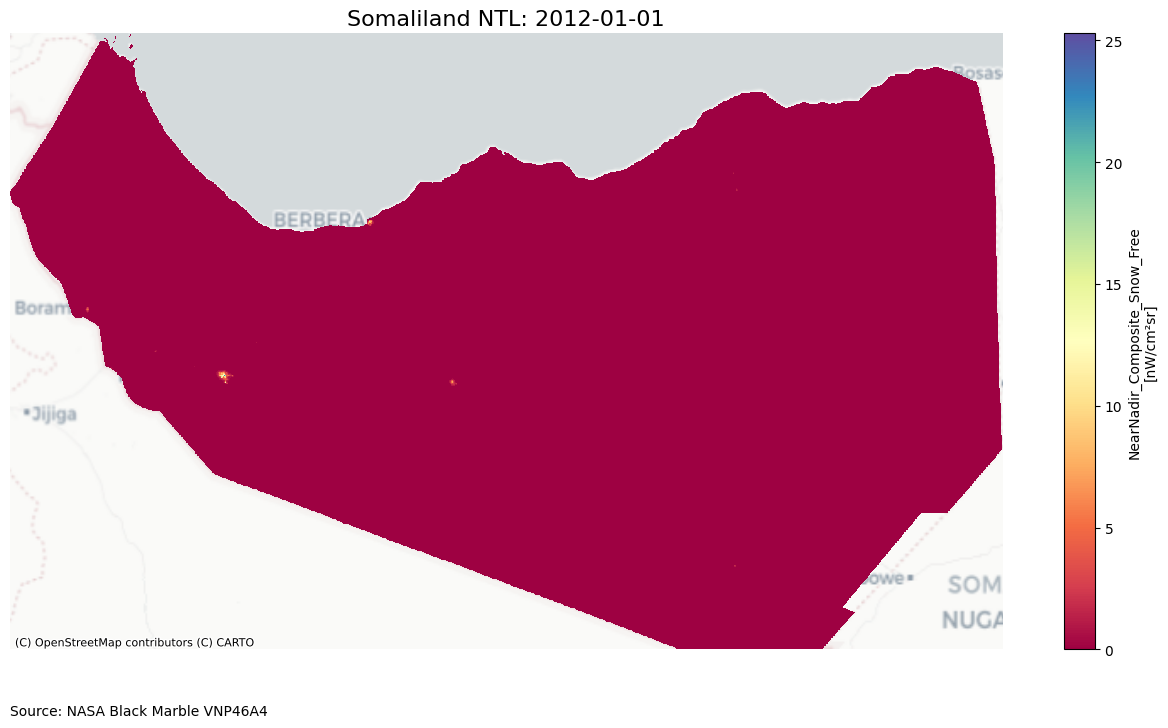

In [9]:
plot_NASA_NTL(SL_berbera, somaliland_shp_berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)

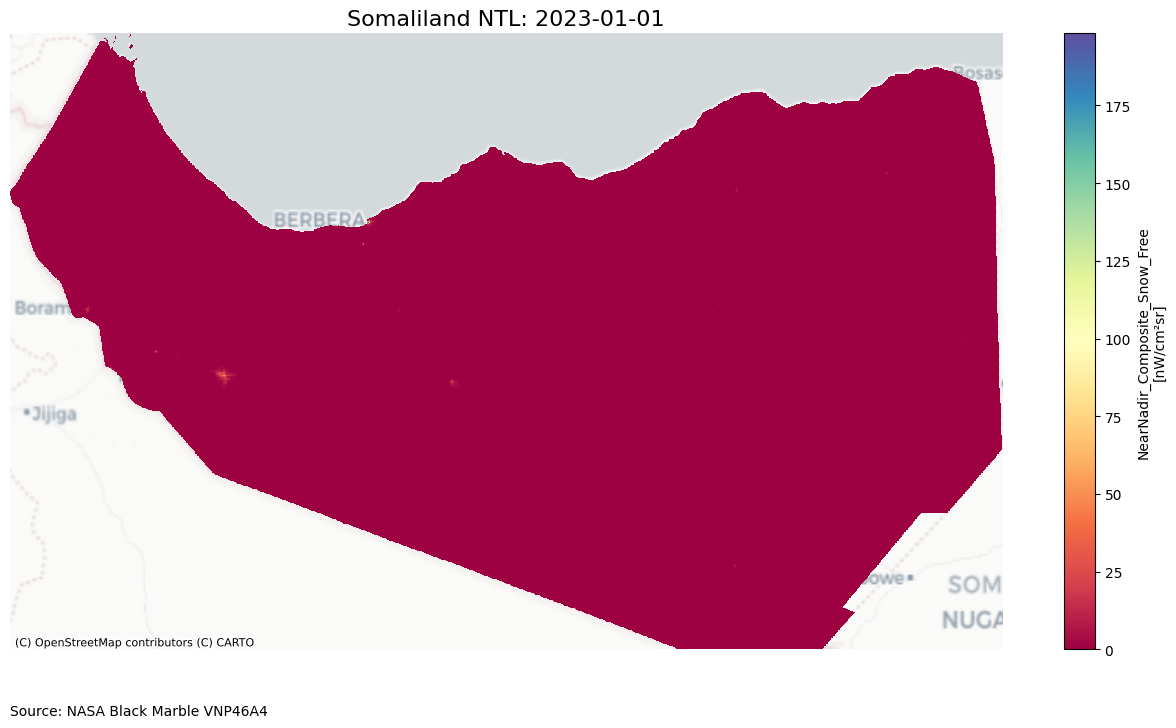

In [17]:
plot_NASA_NTL(SL_berbera, somaliland_shp_berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)

In [ ]:
values2012 = SL_berbera["NearNadir_Composite_Snow_Free"].sel(time="2012-01-01").values.flatten()
values2012 = values2012[~np.isnan(values2012)]
values2012 = values2012[values2012 > 0]

values2023 = SL_berbera["NearNadir_Composite_Snow_Free"].sel(time="2023-01-01").values.flatten()
values2023 = values2023[~np.isnan(values2023)]
values2023 = values2023[values2023 > 0]

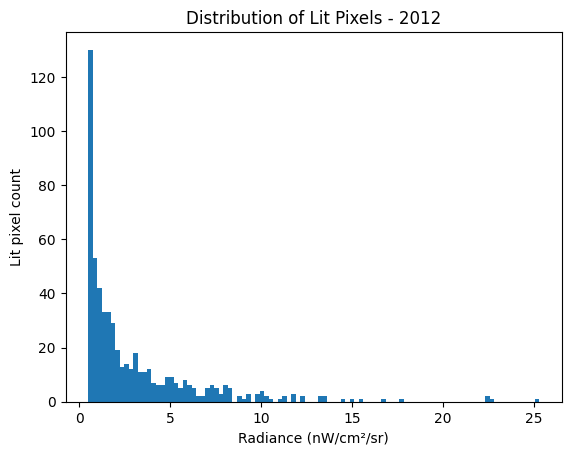

In [ ]:
plt.hist(values2012, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2012")
plt.show()

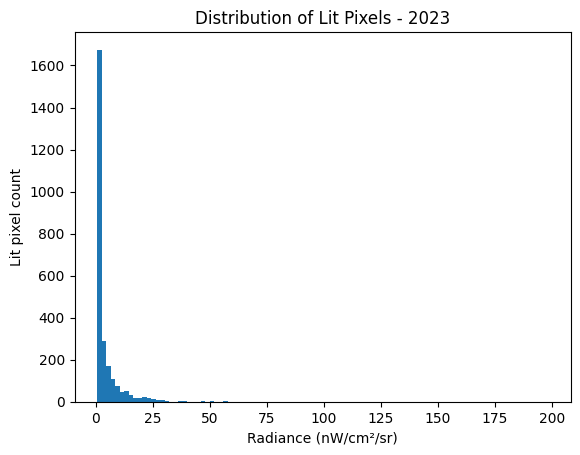

In [ ]:
plt.hist(values2023, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2023")
plt.show()

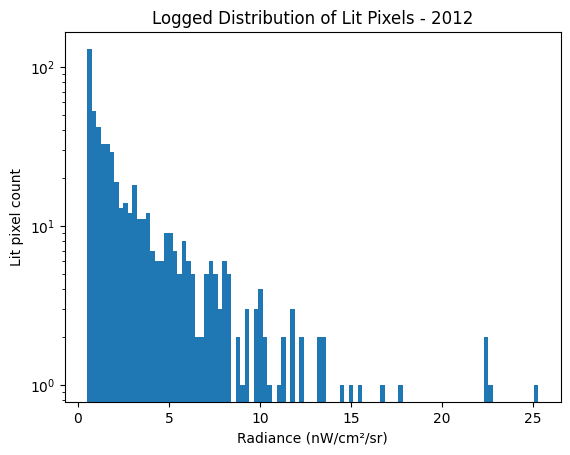

In [ ]:
plt.hist(values2012, bins=100, log=True)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Logged Distribution of Lit Pixels - 2012")
plt.show()

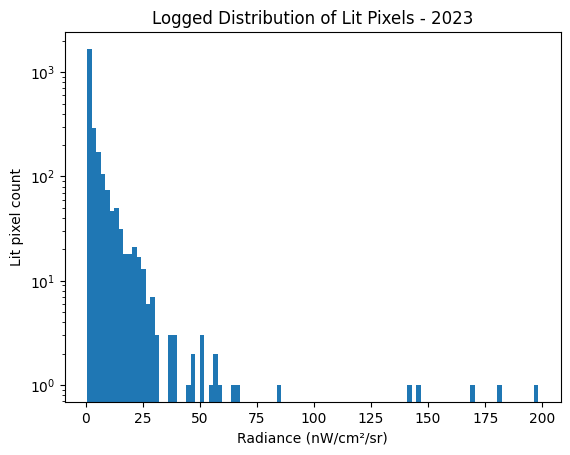

In [ ]:
plt.hist(values2023, bins=100, log=True)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Logged Distribution of Lit Pixels - 2023")
plt.show()

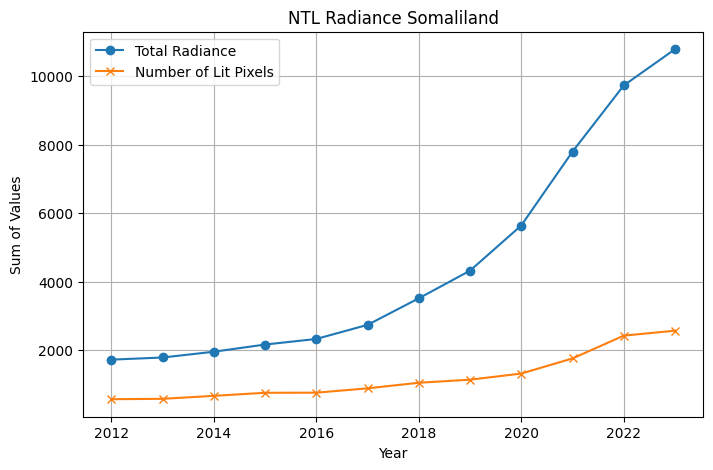

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).values, marker="o")
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), (SL_berbera["NearNadir_Composite_Snow_Free"] > 0).sum(dim=["x", "y"]).values, marker="x")
plt.title("NTL Radiance Somaliland")
plt.xlabel("Year")
plt.ylabel("Sum of Values")
plt.legend(["Total Radiance", "Number of Lit Pixels"])
plt.grid(True)
plt.show()

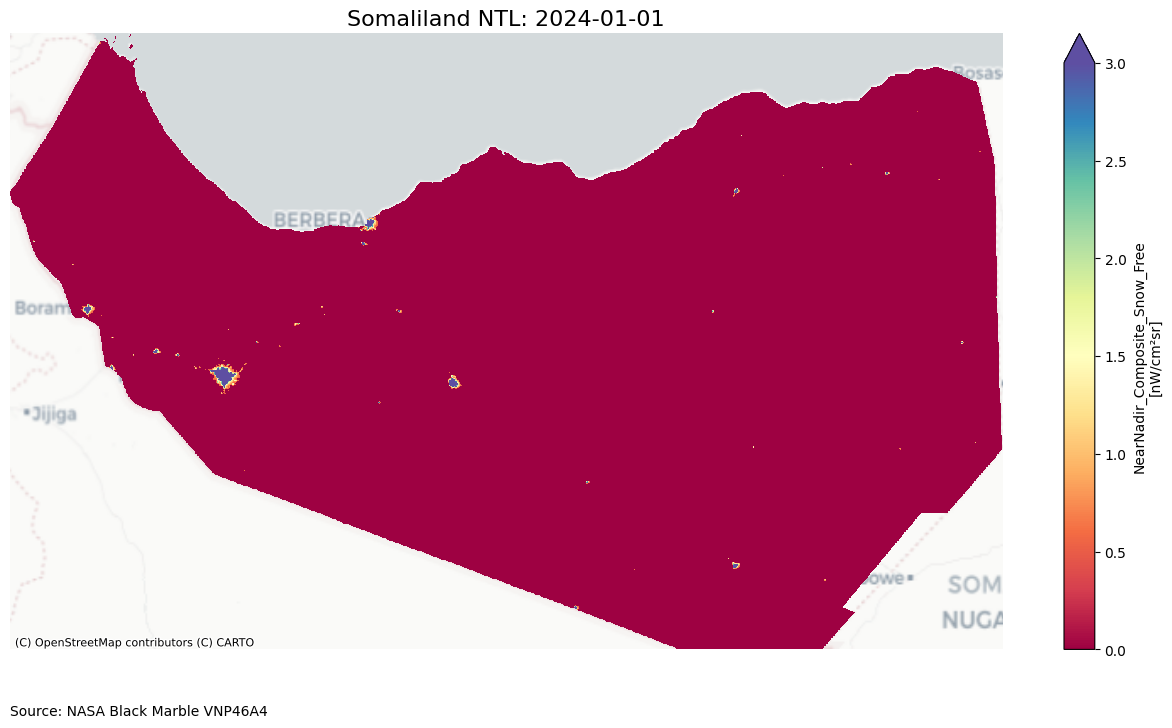

## Exploring Data Quality

### Annual Data

In [12]:
years = range(2012, 2025)
rows = []
for year in years:
    values = SL_An_Qual["NearNadir_Composite_Snow_Free_Quality"].sel(time=f"{year}-01-01").values.flatten()
    values = values[~np.isnan(values)]
    rows.extend((year, v) for v in values)

df = pd.DataFrame(rows, columns=["Year", "Value"])
counts = df.value_counts(["Year", "Value"]).reset_index(name="Count")
pivoted = counts.pivot(index="Year", columns="Value", values="Count").fillna(0)


#NearNadir_Composite_Snow_Covered_Quality:Description = "Quality:\n\t  0 = Good quality\n\t  1 = Poor quality\n\t  2 = Gap filled\n\t  
#255 = Fill value\n\t"
pivoted


Value,0.0,1.0,2.0
Year,,,
2012,804162.0,210.0,3.0
2013,804303.0,72.0,0.0
2014,804108.0,248.0,19.0
2015,804357.0,18.0,0.0
2016,804375.0,0.0,0.0
2017,803934.0,431.0,10.0
2018,804202.0,173.0,0.0
2019,804181.0,191.0,3.0
2020,804373.0,2.0,0.0


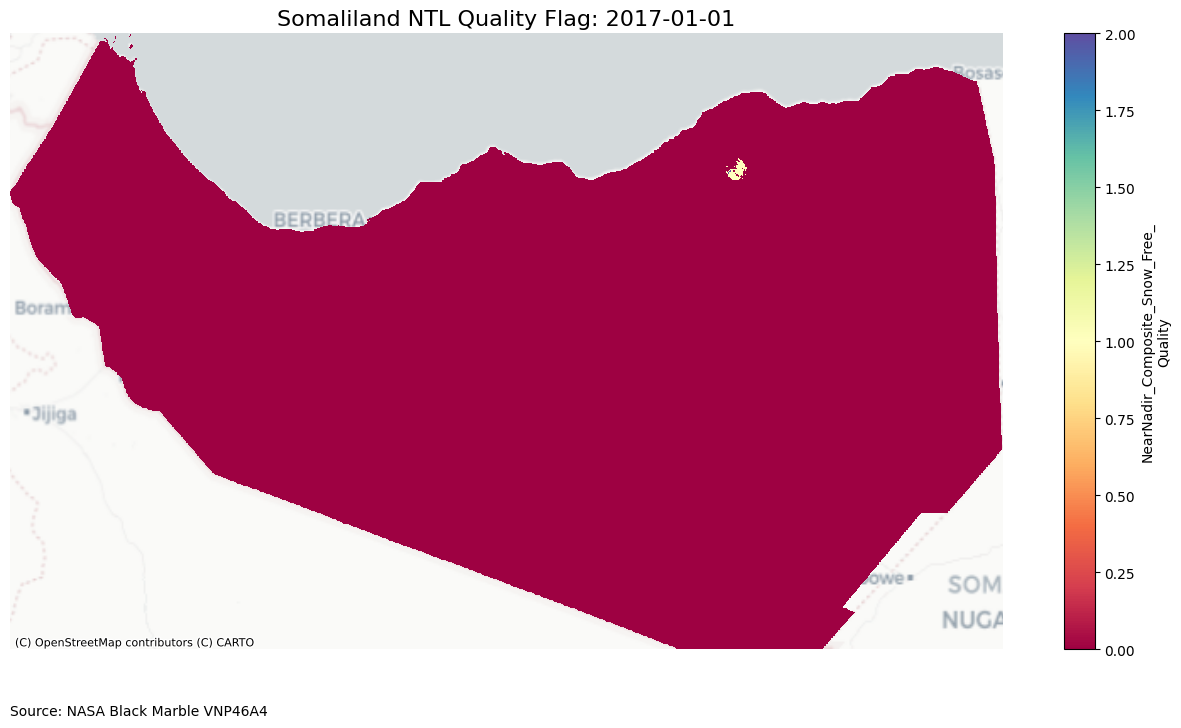

In [13]:
plot_NASA_NTL(SL_An_Qual, somaliland_shp_berbera, date = "2017-01-01", 
              variable = "NearNadir_Composite_Snow_Free_Quality", robust=False, source="VNP46A4", title_prefix="Somaliland NTL Quality Flag")


### Monthly Data

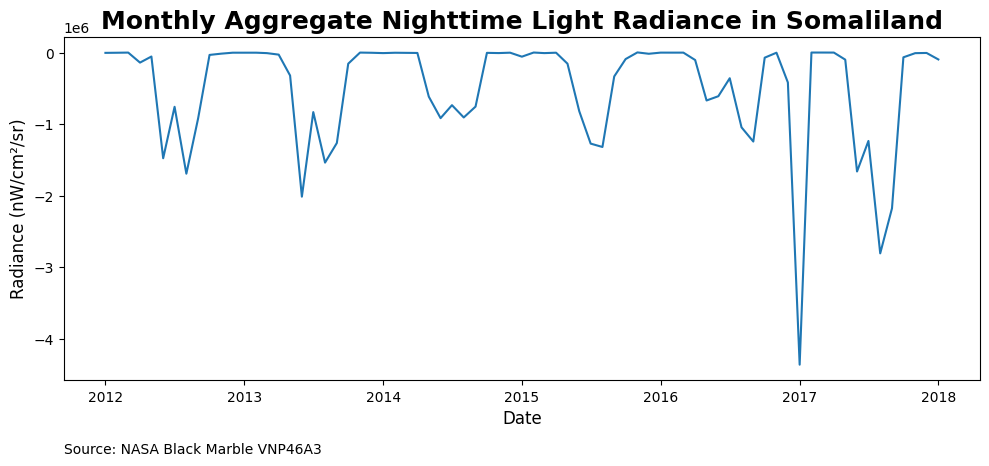

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [13]:
#Examining min values shows that fill values of -999.9 are present in the monthly data. 
print(SL_month["NearNadir_Composite_Snow_Free"].min())
print(SL_month["NearNadir_Composite_Snow_Free"].max())

<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(-999.90002441)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref
<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(37.45820999)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref


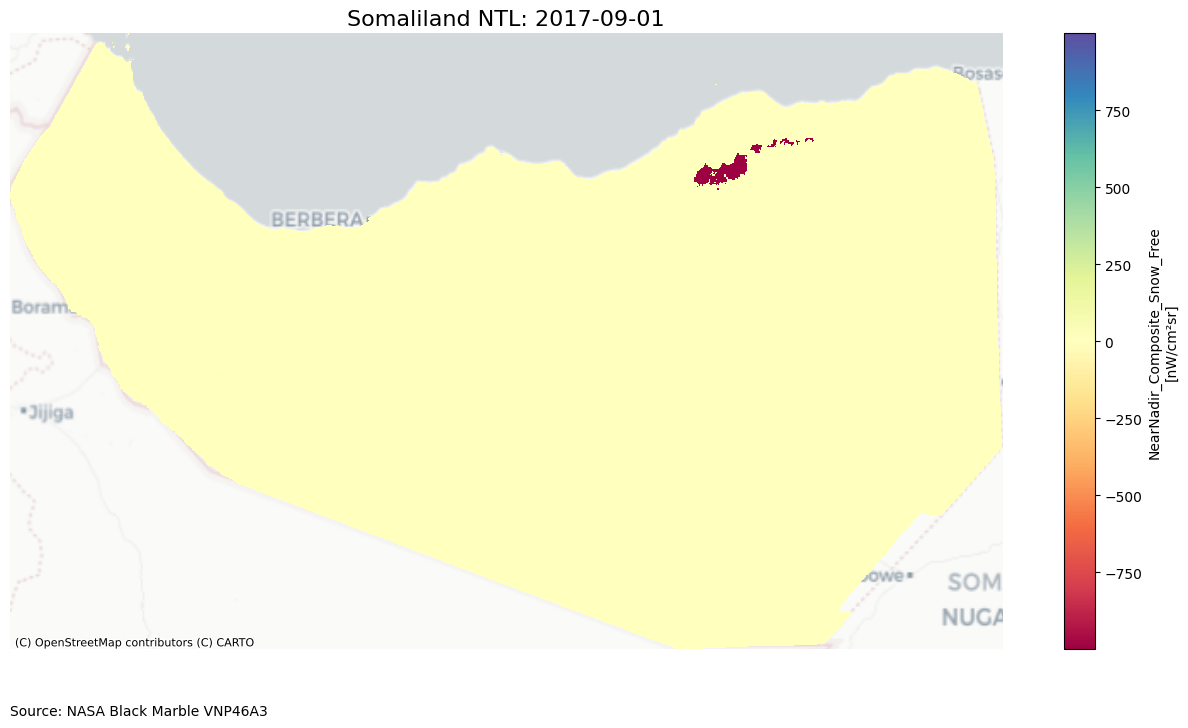

In [14]:
plot_NASA_NTL(SL_month, somaliland_shp_berbera, date = "2017-09-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

In [15]:
#A large amount of fill values are present in the monthly data. Calculating the number of fill values per month.
month_total_pixels = []
month_filled = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_filled.append((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) == SL_month["NearNadir_Composite_Snow_Free"].min()).sum().item())

df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_filled": month_filled,
})

df

,time,month_total_pixels,month_filled
0,2012-01-01,807889,2
1,2012-02-01,807889,1
2,2012-03-01,807889,0
3,2012-04-01,807889,139
4,2012-05-01,807889,57
...,...,...,...
68,2017-09-01,807889,2179
69,2017-10-01,807889,66
70,2017-11-01,807889,11
71,2017-12-01,807889,5


In [16]:
#Even removing the fill values of -999.9, there is a massive variation in total radiance in the monthly data.
clean_SL_month = xr.where(
    SL_month < -999, 
    0, # Assigning 0 for filled values (value of -999.9).
    SL_month 
)


month_total_pixels = []
month_non_zero_pixels = []
month_radiance = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_non_zero_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) > 0).sum().item(), 1))
    month_radiance.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).sum().item(), 1))


df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_non_zero_pixels": month_non_zero_pixels,
    "month_radiance": month_radiance,
})

df


,time,month_total_pixels,month_non_zero_pixels,month_radiance
0,2012-01-01,807889,638,1465.9
1,2012-02-01,807889,1183,2163.4
2,2012-03-01,807889,2937,3345.7
3,2012-04-01,807889,1623,2239.8
4,2012-05-01,807889,5880,5204.3
...,...,...,...,...
68,2017-09-01,807889,1556,2911.4
69,2017-10-01,807889,1323,3223.9
70,2017-11-01,807889,6134,6286.8
71,2017-12-01,807889,932,3115.2


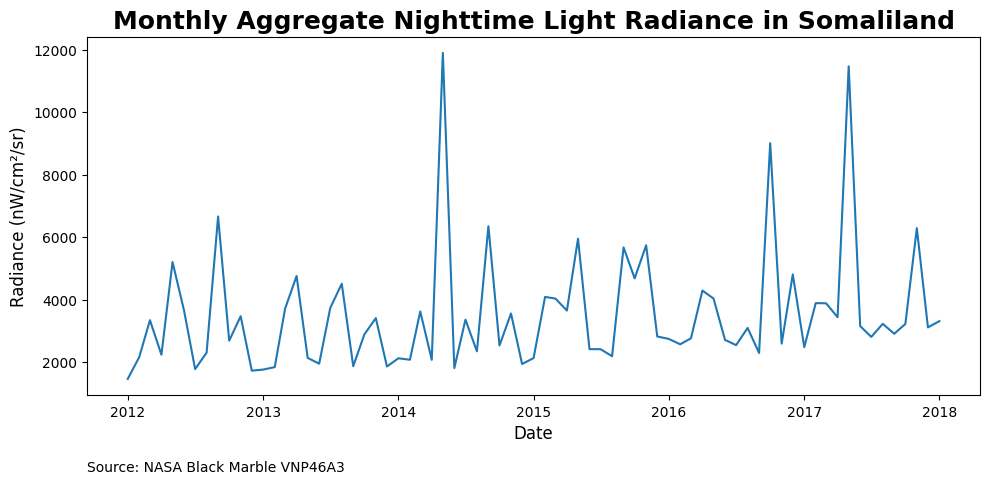

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [18]:
#Selecting the peak months with radiance above 11,000 nW/cm²/sr to understand drivers of variation. 
clean_SL_month.sel(time=clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]) > 11000).time.to_index()

DatetimeIndex(['2014-05-01', '2017-05-01'], dtype='datetime64[ns]', name='time', freq=None)

The graphs below show how there are a large number pixels with much higher values than normal in the Sanaag & Sool regions. 

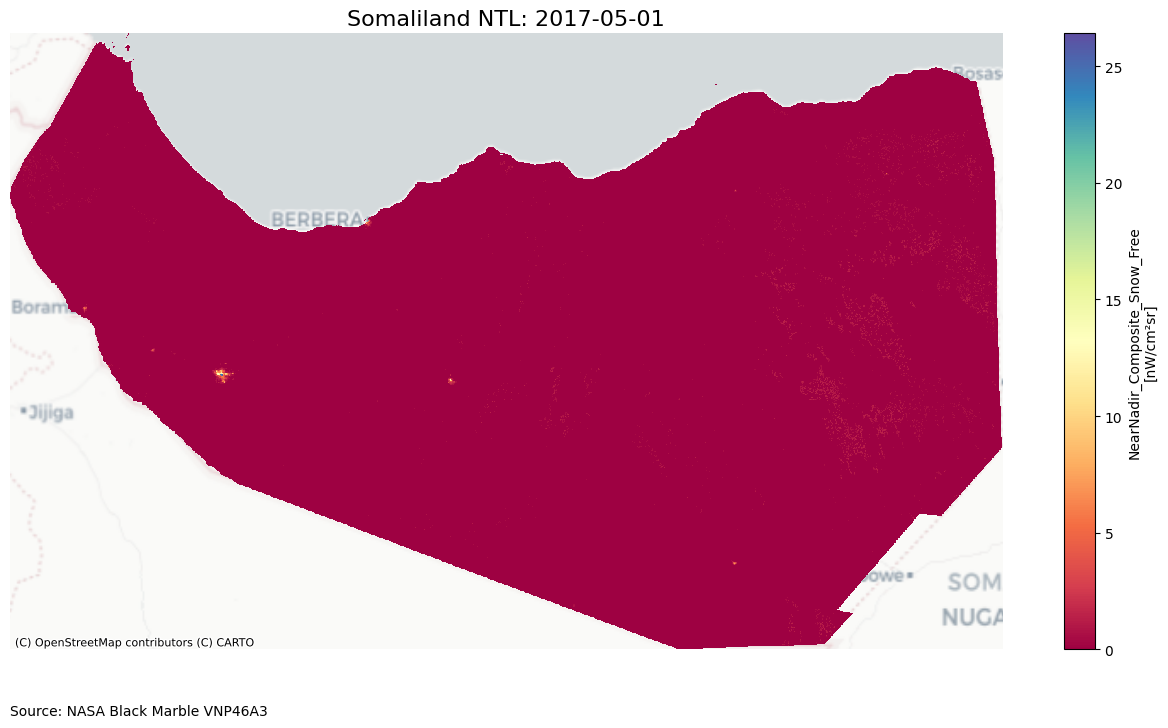

In [19]:
plot_NASA_NTL(clean_SL_month, somaliland_shp_berbera, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

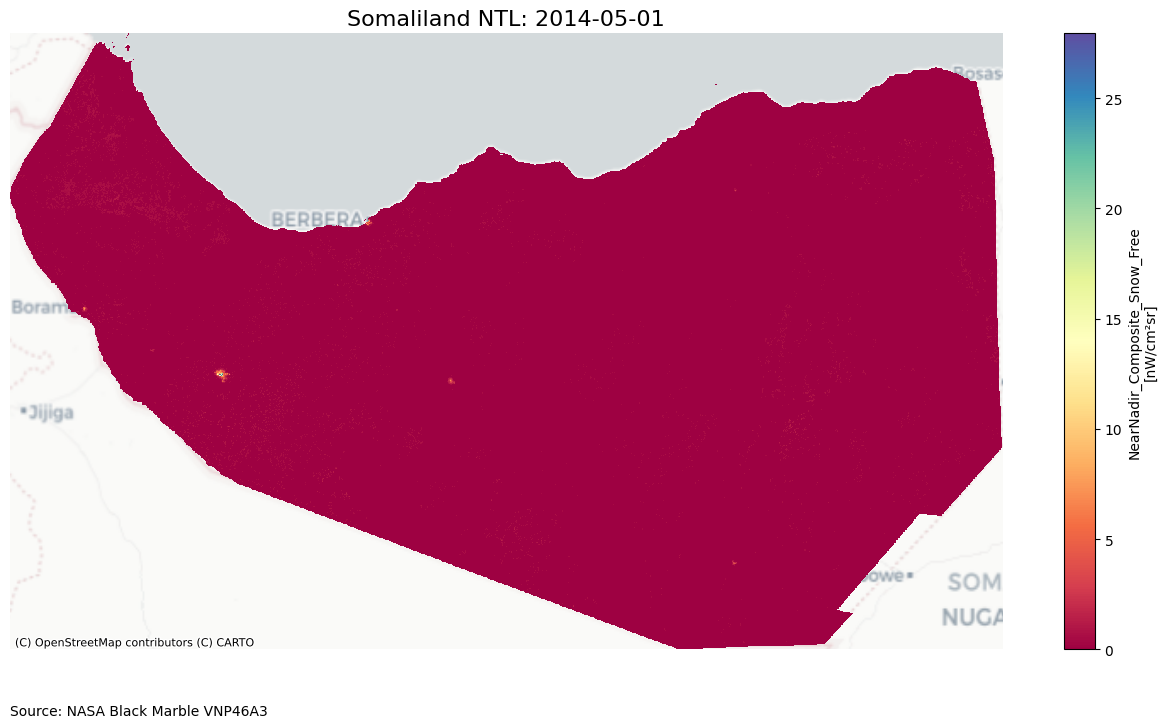

In [20]:
plot_NASA_NTL(clean_SL_month, somaliland_shp_berbera, date = "2014-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

The graph below shows the quality of the observations per pixel. This potentially explains the variation. 
We also show the number of observations per pixel which demonstrates why there is lower quality in the Sanaag area. 

00 Good-quality The number of observations used for the composite is larger than 3.
01 Poor-quality The number of observations used for the composite is less than or equal to 3.
02 Gap filled Gap filled NTL based on historical data.
255 Fill value.


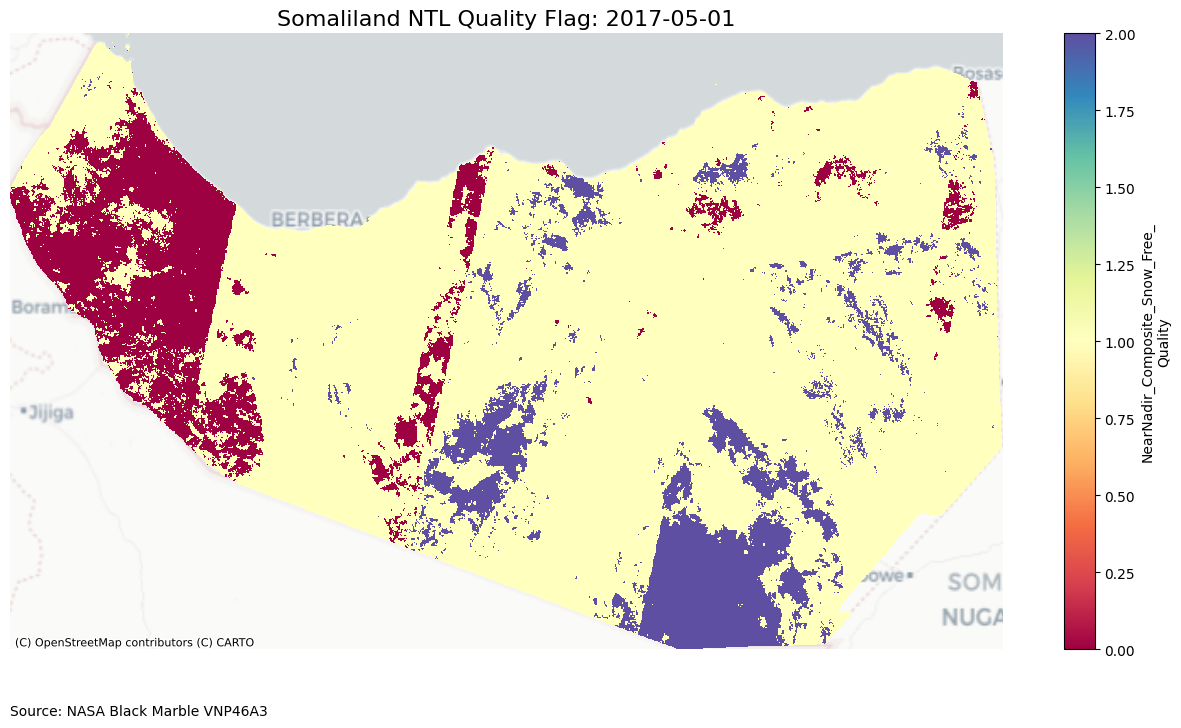

In [14]:
plot_NASA_NTL(SL_qual, somaliland_shp_berbera, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free_Quality", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Quality Flag")

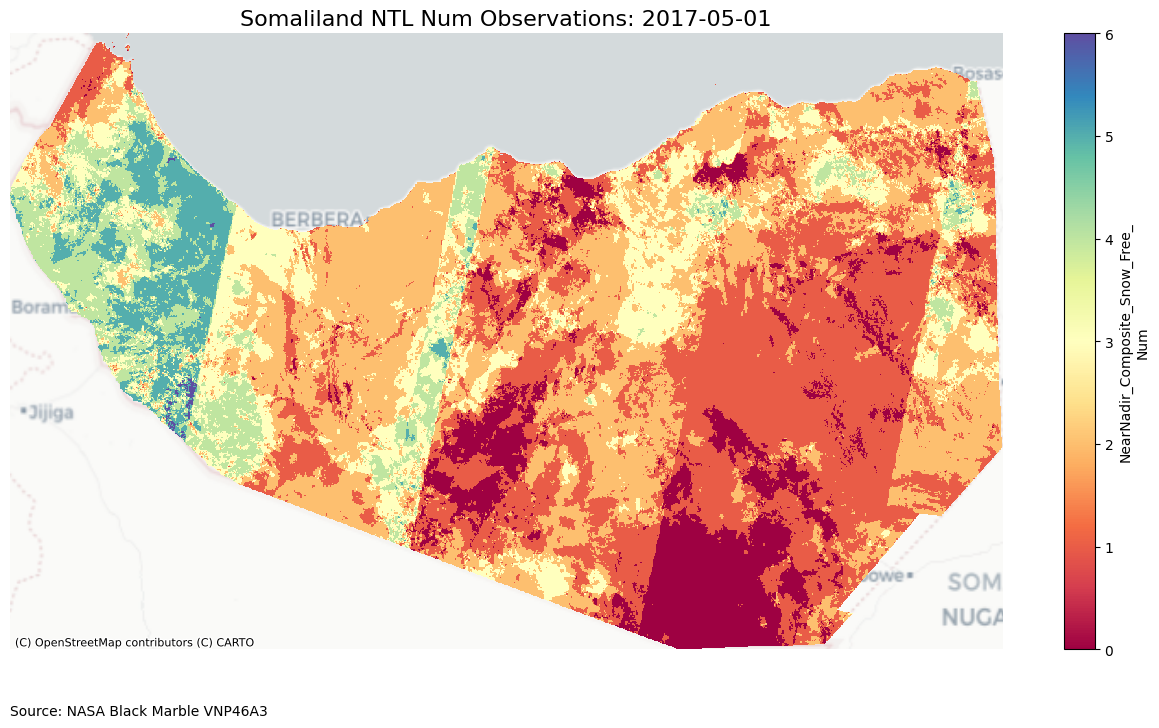

In [15]:
plot_NASA_NTL(SL_num, somaliland_shp_berbera, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free_Num", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Num Observations")
